 Changelog<br>
 Version 0.07<br>
 -Developed AutoRecord superclass<br>
 -Developed LinkRecord class for more general XML retrieval.<br>
 -Built "stringify" in XML core to failsafe against non-string data for serialization (Doesn't want to serialize ints)<br>

Version 0.06<br>
Added robustness to BatchRecord's "get_data"<br>
-Now stores bad queries in a private variable<br>
-Breaks for courtesy using time.sleep<br>
-Pre-calculates record request collisions instead of "AID already in..." for each redundant request.<br>
Included an experiment cell to build a BatchRecord for Cluster A.<br>
Headers and Titles for sections<br>


Version 0.05<br>
"extract_features" changed to "get_features" for consistency.<br>
Changed inspect to not print children backwards.<br>
Built "BatchRecord" object to save and load records.<br>
Added VERBOSE.<br>
Added product_counter<br>
Started work on the ML functions<br>
Added BatchRecord.google_upload() and BatchRecord.google_download()<br>

Version 0.04
Initial version.

# Setup Code/Libraries

In [ ]:
#@title Imports and Global Control { display-mode: "form" }
import urllib3 as urllib
import xml.etree.ElementTree as ET
import certifi
import numpy as np
from collections import Counter
from time import sleep
try:
  from google.colab import files as cfiles
  GOOGLE=True #Are we running this from colab?
except:
  GOOGLE=False

VERBOSE=True

#Proudly stolen from Dr. Cook's PyCuda class code.
from timeit import default_timer as timer
import datetime
from dateutil.tz import gettz
tz = gettz("US/Central")
def timestamp():
    t = datetime.datetime.now(tz)
    return f"{t.strftime('%Y-%m-%d %H:%M:%S')} {tz._ttinfo_dst.abbr}"

print(f'Convenience functions compiled. {timestamp()}')

Convenience functions compiled. 2021-08-24 13:58:50 CDT


In [ ]:
#@title XML Core functions and Nuccore Scraper { display-mode: "form" }

#Version 0.05
#Defined Here:
#    inspect
#    ftree
#    Nuccore_Fetch
#    build_record
#    get_features
#    get_sequence
#    storytime
#    product_search
#    fasta_search
#    fasta_search_2
#    split_record
#    BatchRecord (Class)

def inspect(tree,max_depth=99,max_subs=99,supress_long=True):
    #Feed me-
    #tree- Any XML element.
    #maxdepth- The number of "layers" you want me to walk down the tree.
    #supress_long- Whether or not you want me to cutoff long names/text
    #I give you- A pretty printed output that shows the tree structure.
    q=[(tree,0)]
    while q:
        el,s_num=q.pop()
        if s_num>max_depth:
            continue
        indent="\t"*s_num
        if len(el)>0:
            if len(el)>max_subs and s_num<max_depth:
              subs=f'({max_subs}/{len(el)})'
            else:
              subs=f'({len(el)})'
        else:
            subs=''
        if el.text:
            if supress_long and len(el.text.strip())>32:
                    print(f'{indent}{el.tag} {subs}: "{el.text.strip()[:32]}..."')
            else:
                print(f'{indent}{el.tag} {subs}: "{el.text.strip()}"')
        else:
            print(f'{indent}{el.tag} {subs}')
        if el.attrib:
            for k,cv in el.attrib.items():
                v=str(cv) #Coerce in case it's an int.
                if supress_long and len(v)>32:
                    print(f'{indent}\t{k} -> {v[:32]}...')
                else:
                    print(f'{indent}\t{k} -> {v}')
        for item in reversed(el[:max_subs]):
            q.append((item,s_num+1))

def ftree(tree):
    #Finds the family tree of a given tree.
    return dict((c, p) for p in tree.getiterator() for c in p)

def split_record(record):
    #Don't touch this one, this is just a really common step used in the other ones.
    return record.find('feature_table'),record.find('sequence')


def stringify(el):
    #Turns all of an elements attributes into strings
    for k,v in el.attrib.items():
      el.attrib[k]=str(v)
    el.text=str(el.text)
    for sub in el:
      stringify(sub)

def Nuccore_Fetch(id_string):
    #Feed me- A string containing an Acession ID.
    #I give you- A raw "block" of XML that needs to be cleaned by build_record.
    base="https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?"
    parms={"db":"nuccore","rettype":"gp","retmode":"xml"}
    parms["id"]=id_string
    #Pack the request
    req=base+'&'.join([f'{k}={v}' for k,v in parms.items()])
    pool = urllib.PoolManager(cert_reqs='CERT_REQUIRED',ca_certs=certifi.where())
    res = pool.request('GET', req)
    if res.status==200: #Return if we didn't get an error.
        return ET.fromstring(res.data)
    else:
        return False #Return if it didn't work out.

def build_record(block):
    #Feed me-That thing Nuccore_Fetch outputs
    #I give you-The simplified GeneRecord element.
    res=ET.Element('GeneRecord') #Build a thing to return.
    ftable=get_features(block) #Extract the features
    res.append(ftable) #Put 'em in res.
    seq=get_sequence(block) #Extract the sequence.
    res.append(seq) #Put it in res.
    name=block.find('GBSeq/GBSeq_organism').text
    res.set('name',name) #Set the name.
    id_num=block.find('GBSeq/GBSeq_primary-accession').text
    res.set('accession',id_num)
    return res

def get_features(tabl):
    #This is ONLY used by build_record.
    #Feed me- The thing output by Nuccore_Fetch
    #I give you- The "feature_table" thing from the GeneRecord
    #f_list=tabl.find('GBSeq/GBSeq_feature-table')
    res=ET.Element('feature_table')
    parents=ftree(tabl) #We need to jump backwards sometimes, so we need to know this.
    #for feature in f_list.findall('GBFeature'):
    for feature in tabl.findall('.//GBFeature'):
        nfeature=ET.Element('feature')
        #Get the feature's range, right and left endpoints
        left=feature.find('GBFeature_intervals/GBInterval/GBInterval_from').text
        right=feature.find('GBFeature_intervals/GBInterval/GBInterval_to').text
        if int(left)>int(right): #Figure out whether it's forwards or backwards
            nfeature.set('forwards','False') #Let me know it's backwards.
            left,right=right,left #Flip it around before we set if it's backwards.
        else:
            nfeature.set('forwards','True') #Let me know it's forwards.
        nfeature.set('from',left) #Set the endpoints
        nfeature.set('to',right)
        found_product,found_gene=False,False
        #Get the feature's product
        quals=feature.findall("GBFeature_quals/GBQualifier/GBQualifier_name") #Find the "detail" lines on all features.
        for qual in quals:
            if qual.text=='product':
                found_product=True
                pqual=parents[qual] #Get the root qualifier.
                nfeature.set('product',pqual.find('GBQualifier_value').text)
            elif qual.text=='gene':
                found_gene=True
                pqual=parents[qual] #Get the root qualifier.
                nfeature.set('gene',pqual.find('GBQualifier_value').text)
        if not found_product:
            nfeature.set('product','')
        if not found_gene:
            nfeature.set('gene','')
        if found_product or found_gene: #Only attach if we've found one detail line, at least.
            res.append(nfeature)
    return res

def get_sequence(tabl):
    #This is ONLY used by build_record.
    #Feed me- The thing output by Nuccore_Fetch
    #I give you- The "sequence" thing from the GeneRecord
    seq=tabl.find('GBSeq/GBSeq_sequence')
    return ET.Element('sequence',attrib={'contents':seq.text.upper()})

def storytime(record):
    #This spits out all the known features along with their indicies and products.
    #Note- This is mostly for demonstrational purposes. I don't actually need this.
    #Feed me- A GeneRecord-type Element
    #I give you- A pretty-printed list of all the features and their products.
    features,sequence=split_record(record)
    raw=sequence.get('contents')
    for item in features.findall('feature'): #Iterate over feature table
        start=int(item.get('from'))
        end=int(item.get('to'))
        if item.get('forwards')=='True':
            arrow='-->'
        else:
            arrow='<--'
        subseq=raw[start-1:end] #Indexed from 0 vs 1.
        product=item.get('product')
        print(f'{product}\t{start}{arrow}{end}\n{subseq}\n')


def product_search(record,tag):
    #This is just in here for explanatory purposes.
    features=record.find('feature_table')
    match_list=features.findall(f"feature[@product='{tag}']")
    if match_list:
        for item in match_list:
            inspect(item)

def product_counter(record):
  cnts=Counter()
  features,_=split_record(record)
  for feature in features:
    key=feature.get('product')
    cnts[key] += 1
  return cnts

def fasta_search(record,tag):
    #Feed me- A GeneRecord Element, and a tag to search for (like "DNA primase")
    #I give you- A fasta-flavored printing of the product features.
    features,seq=split_record(record)
    accession=record.get('accession') #Get accession number
    match_list=features.findall(f"feature[@product='{tag}']")
    raw=seq.get('contents')
    if match_list:
        for item in match_list:
            gene_num=item.get('gene')
            start=int(item.get('from'))
            end=int(item.get('to'))
            if start>end:
                start,end=end,start #Flip it around!
            print(f">{accession} {gene_num}\n{raw[start-1:end]}")

def fasta_search_2(record,tag):
    #Jaryd's version of fasta_search
    #Retained for reference purposes
    features,seq=split_record(record)
    accession=record.get('accession')
    match_list=features.findall(f"feature[@product='{tag}']")
    sequ=seq.get('contents')
    if match_list:
        for i in match_list:
            print(f""">{accession} {i.get('gene')}\n
                  {sequ[int(i.get('from'))-1:int(i.get('to'))]}""")


class AutoRecord(object):
    @property
    def nickname(self):
        return "Undefined AutoRecord"
    def __init__(self,fpath):
        self.fpath=fpath
        self.root=None #Leave a placeholder
        self.load() #Load the file and get the root.
        self._bad_queries=set()
        if not self.root:
          self.root=ET.Element(self.nickname)
    def __repr__(self): #What do you want me to print?
        return self.root.__repr__() #Just show me what the root is.
    def __iter__(self): #How do you want me to loop?
        return (item for item in self.root) #Gives rudimentary iterator behavior.
    def save(self):
        stringify(self.root)
        with open(self.fpath,'wb') as targ: #Try to save it
            targ.write(ET.tostring(self.root))
        if VERBOSE:
            print('Save successful!')
    def load(self):
        try:
          with open(self.fpath,'rb') as src: #Try to load it.
              self.root=ET.fromstring(src.read()) #Dump into file.
          if VERBOSE:
              print(f'{self.nickname} loaded.')
        except:
          if VERBOSE:
            print(f'{self.nickname} could not be loaded successfully.\nCreating empty root.')
          self.root=ET.Element(self.nickname)
    def google_download(self):
      self.save()
      if GOOGLE:
         cfiles.download(self.fpath)
      else:
         print("You aren't running this from CoLab. Why are you trying this?")
    def google_upload(self):
      robj=cfiles.upload()
      print(robj)
      keys=list(robj.keys()) #I don't care what they're called.
      if len(keys)==0:
        print('Download cancelled.')
        return
      raw=robj[keys[0]]
      self.root=ET.fromstring(raw) #Make that the new root.
      self.build_index() #Rebuild our index.

class LinkRecord(AutoRecord):
    @property
    def nickname(self):
        return self.name
    def __init__(self,fpath,name='LinkRecord'):
        self.name=name
        AutoRecord.__init__(self,fpath)

class BatchRecord(AutoRecord):
    def __init__(self,fpath):
        self.index=None
        AutoRecord.__init__(self,fpath)
        if not self.index:
          self.build_index()
    def load(self):
        AutoRecord.load(self)
        self.build_index()
    @property
    def nickname(self):
        return "BatchRecord"
    def build_index(self):
        #Builds the index for our BatchRecord so that we can more easily determine what's in there.
        self.index={}
        for child in self.root: #For each child
            aid=child.get('accession') #Get the child's name
            self.index[aid]=child #Index it for quicker finding.
    @property
    def contents(self): #The names of the known records.
        return set(self.index.keys())
    def rebuild(self,purge=False):
        temp_inds=self.contents
        self.root=ET.Element('BatchRecord')
        self.index={}
        if not purge: #Just rebuild with the known list
          if VERBOSE:
            print('Rebuilding the entire database from scratch...')
          self.get_data(*temp_inds)
    def get_data(self,*args):
        check=self.contents #Dump current index into a checker node.
        #Preprocess the arguments to cut down on how much we print.
        argset=set(args)
        re_calls=self.contents.intersection(argset) #Redundancies
        print(f'{len(re_calls)} records already in database.')
        argset=argset.difference(re_calls)
        for arg in argset:
            if arg in check:
                if VERBOSE:
                    print(f'AID {arg} already in database.')
                continue
            new_raw=Nuccore_Fetch(arg)
            try:
              new_node=build_record(new_raw)
            except:
              if VERBOSE:
                print(f'AID {arg} could not be successfully converted.')
              self._bad_queries.add(arg)
              sleep(5) #Longer sleep so they might forgive us.
              continue
            self.root.append(new_node)
            sleep(2) #Adds a sleep so they don't knock me off.
            if VERBOSE:
              name=new_node.get('name')
              print(f'Added {arg}-{name} to BatchRecord.')
              if name in self._bad_queries:
                self._bad_queries.remove(name)
    def google_upload(self,integrate=False):
      if integrate:
        print('This feature is currently not supported.')
      robj=cfiles.upload()
      print(robj)
      keys=list(robj.keys()) #I don't care what they're called.
      if len(keys)==0:
        print('Download cancelled.')
        return
      if len(keys)>1:
        print('Multi-Record integration not currently supported')
      raw=robj[keys[0]]
      self.root=ET.fromstring(raw) #Make that the new root.
      self.build_index() #Rebuild our index.

print(f'XML functions compiled. {timestamp()}')

XML functions compiled. 2021-08-24 13:58:52 CDT


In [ ]:
#@title ML Preprocessing functions { display-mode: "form" }
nuc_num=dict([(v,i) for i,v in enumerate('ATCG')])
nuc_onehot=np.fliplr(np.eye(4,dtype=int))
def nuc_encode(seq):
    inds=[nuc_num[v] for v in seq]
    return nuc_onehot[inds]

print(f'ML functions compiled. {timestamp()}')

ML functions compiled. 2021-08-24 13:58:52 CDT


# Beginning of Experimental Code

In [ ]:
#@title EX-Restore record from local file. { display-mode: "form" }
fpath='Database.xml'
bank=BatchRecord(fpath)
bank.google_upload()
bank.save()

BatchRecord could not be loaded successfully.
Creating empty root.


Saving Database.xml to Database.xml


IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.

Current values:
NotebookApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
NotebookApp.rate_limit_window=3.0 (secs)



Save successful!


In [ ]:
#@title EX-Build Cluster A record from scratch. { display-mode: "form" }
import pandas as pd
#Step 1: Download from https://phagesdb.org/data/
# The list of phage names with accession numbers:
# Full List of GenBank Accession Numbers > With phage names "PhagesDB_accession_numbers"
# Simple (just phage names and clusters) Tab-Delimited Text Files > All sequenced phages "PhagesDB_Data"
#Note: If you already have these uploaded to CoLab, comment out this line.
uploads=cfiles.upload()
#Step 2: If those files are uploaded, you can now get all Cluster A Accession numbers using some pandas tricks.
pdb_accession=pd.read_csv('PhagesDB_accession_numbers.txt',delimiter='\t',names=('phage_name','accession_ID','???'))
pdb_cluster = pd.read_csv('PhagesDB_Data.txt',delimiter='\t') #This one has a header for some reason
pdb_cluster.columns=('phage_name','cluster','subcluster')
cluster_A_names=pdb_cluster[pdb_cluster.cluster=='A'].phage_name.tolist()
cluster_A_aids=pdb_accession[pdb_accession.phage_name.isin(cluster_A_names)].accession_ID.tolist()
print(pdb_cluster.head())
print(pdb_accession.head())
print(len(cluster_A_aids))
print(cluster_A_aids) #Got it!
#Now that we've verified it works, build the bank
bank=BatchRecord('Database.xml')
print(bank.contents)
no_problems=True
GETMAX=-1
try:
  if GETMAX>0:
    bank.get_data(*cluster_A_aids[:GETMAX]) #If a limit was set, grab up to that limit
  else:
    bank.get_data(*cluster_A_aids) #If limit was -1, grab everything.
except Exception:
  print(Exception.args)
  no_problems=False
if no_problems:
  print('Loading complete. Saving the bank internally.')
else:
  print('Some problems encountered during the scrape. Saving what I can.')
bank.save()
bank.google_download()

#Stickynoted bad queries from run on 7-15-2019: 'MN062706','MN062708','MK967395','MN096368','MN096372','MK967399','MK967401','MN062710','MN062712','MK967387','MN096376','MK967382','MN062718'

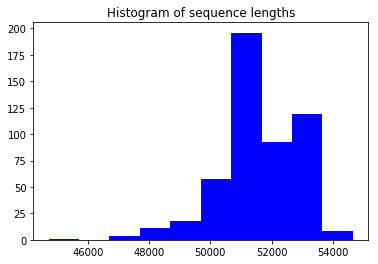

Largest sequence Length:54655.0
Shortest sequence length:44716.0


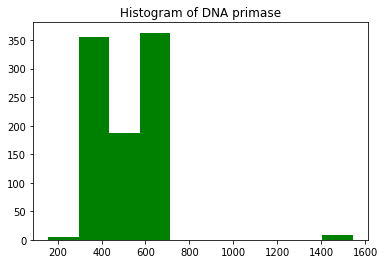

Largest feature Length:1544
Shortest feature length:158


In [ ]:
#@title EX-Summary Statistics on DNA Primase. { display-mode: "form" }
from matplotlib import pyplot as plt
#Consider the length of each gene sequence
res=bank.root.findall('./GeneRecord/sequence')
l_vals=np.zeros(len(res),dtype=float)
for ind,item in enumerate(res):
  seq=item.get('contents')
  l_vals[ind]=len(seq)
plt.title('Histogram of sequence lengths')
plt.hist(l_vals,color='blue')
plt.show()
print(f'Largest sequence Length:{np.max(l_vals)}\nShortest sequence length:{np.min(l_vals)}')

#I want to know how long a DNA primase feature can be.
res=bank.root.findall("./GeneRecord/feature_table/feature[@product='DNA primase']")
dnap_len=[]
for item in res:
  frm=int(item.get('from'))
  to=int(item.get('to'))
  dnap_len.append(to-frm)
plt.title('Histogram of DNA primase')
plt.hist(dnap_len,color='green')
plt.show()
print(f'Largest feature Length:{np.max(dnap_len)}\nShortest feature length:{np.min(dnap_len)}')



In [ ]:
#@title EX-BatchRecord preprocessing to build training data { display-mode: "form" }
#Create a Group of "Snippets"
snips=LinkRecord('Simple.xml','RawData')
root=snips.root
for item in bank.root:
  ns=ET.Element('SequenceData')
  dnap=item.findall("./feature_table/feature[@product='DNA primase']")
  mx_len=0
  start,end=-1,-1 #Where we found the longest.
  for feat in dnap:
    frm=int(feat.get('from'))
    to=int(feat.get('to'))
    sz=to-frm
    if sz>mx_len: #If this one is the longer
      mx_len=sz
      start=frm
      end=to
  ns.set('name',item.get('name'))
  ns.set('accession',item.get('accession'))
  ns.set('start',start)
  ns.set('end',end)
  ns.set('f_count',len(dnap))
  ns.set('f_length',mx_len)
  ns.set('sequence',item.find('sequence').get('contents'))
  ns.set('length',len(ns.get('sequence')))
  root.append(ns)
cntr=Counter()
for item in snips:
  i=item.get('f_count')
  cntr[i] += 1
print(cntr)
snips.save()

RawData could not be loaded successfully.
Creating empty root.
Counter({2: 432, 1: 56, 0: 20})
Save successful!


In [ ]:
table = {
        'ATA':'I', 'ATC':'I', 'ATT':'I', 'ATG':'M',
        'ACA':'T', 'ACC':'T', 'ACG':'T', 'ACT':'T',
        'AAC':'N', 'AAT':'N', 'AAA':'K', 'AAG':'K',
        'AGC':'S', 'AGT':'S', 'AGA':'R', 'AGG':'R',
        'CTA':'L', 'CTC':'L', 'CTG':'L', 'CTT':'L',
        'CCA':'P', 'CCC':'P', 'CCG':'P', 'CCT':'P',
        'CAC':'H', 'CAT':'H', 'CAA':'Q', 'CAG':'Q',
        'CGA':'R', 'CGC':'R', 'CGG':'R', 'CGT':'R',
        'GTA':'V', 'GTC':'V', 'GTG':'M', 'GTT':'V',
        'GCA':'A', 'GCC':'A', 'GCG':'A', 'GCT':'A',
        'GAC':'D', 'GAT':'D', 'GAA':'E', 'GAG':'E',
        'GGA':'G', 'GGC':'G', 'GGG':'G', 'GGT':'G',
        'TCA':'S', 'TCC':'S', 'TCG':'S', 'TCT':'S',
        'TTC':'F', 'TTT':'F', 'TTA':'L', 'TTG':'M',
        'TAC':'Y', 'TAT':'Y', 'TAA':'_', 'TAG':'_',
        'TGC':'C', 'TGT':'C', 'TGA':'_', 'TGG':'W',
    } #An amino-acid table prioritizing possible Methianine sequences.\
cntr=Counter()
tdat=0
for example in snips:
  seq=example.get('sequence')
  sz=len(seq)
  cntr[sz%3] += 1
  trans_seq=map(table.get,(seq[v:v+3] for v in range(0,sz,3)))
  trans_seq=np.array(list(trans_seq))
  locs=np.where(trans_seq=='M')[0]*3
  tdat += len(locs)
print(tdat)
print(cntr)

326123
Counter({1: 180, 2: 174, 0: 154})


Random searches we used for help:
- https://www.geeksforgeeks.org/dna-protein-python-3/